<a href="https://colab.research.google.com/github/JESUSJEREZ/TALLER_UNIR/blob/main/Taller_1_de_Ingenieria_y_Procesado_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Taller 1 Ingenieria y Procesado de Datos: HDFS, Spark SQL y MLlib##

Lee con detenimiento cada ejercicio. Las variables utilizadas para almacenar las soluciones, al igual que las nuevas columnas creadas, deben llamarse **exactamente** como indica el ejercicio, o de lo contrario los tests fallarán y el ejercicio no puntuará. Debe reemplazarse el valor `None` al que están inicializadas por el código necesario para resolver el ejercicio.

# **INSTALACIÓN DEL HADOOP**

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

# **INSTALACIÓN DEL PY SPARK**


In [ ]:
!pip install pyspark

Se importan las librerias con pyspark y a su vez se genera el sparksession que nos permite tener trnsaccionalidad con el ecosistema hadoop

In [ ]:
from pyspark.context  import SparkContext
from pyspark.sql.session import SparkSession
sc=SparkContext('local')
spark=SparkSession(sc)

## Leemos el fichero flights.csv que hemos subido a HDFS

In [ ]:
path_file="flights_act1.csv"

flights_act1DF=spark.read.option("header","true").option("inferSchema", "true").csv(path_file)

Indicamos que contiene encabezados (nombres de columnas) y que intente inferir el esquema, aunque después comprobaremos si lo
ha inferido correctamente o no. La ruta del archivo en HDFS debería ser /<nombre_alumno>/flights.csv

Imprimimos el esquema para comprobar qué tipo de dato ha inferido en cada columna

In [ ]:
flights_act1DF.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- dep_time: string (nullable = true)
 |-- dep_delay: string (nullable = true)
 |-- arr_time: string (nullable = true)
 |-- arr_delay: string (nullable = true)
 |-- carrier: string (nullable = true)
 |-- tailnum: string (nullable = true)
 |-- flight: integer (nullable = true)
 |-- origin: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- air_time: string (nullable = true)
 |-- distance: integer (nullable = true)
 |-- hour: string (nullable = true)
 |-- minute: string (nullable = true)



Mostramos el número de filas que tiene el DataFrame para hacernos una idea de su tamaño:

In [ ]:
flights_act1DF.count()

162049

Vemos que tenemos 162049 filas. Si imprimimos por pantalla las 5 primeras filas, veremos qué tipos parecen tener y en qué columnas no coincide el tipo que podríamos esperar con el tipo que ha inferido Spark.

In [ ]:
flights_act1DF.show(5)

+----+-----+---+--------+---------+--------+---------+-------+-------+------+------+----+--------+--------+----+------+
|year|month|day|dep_time|dep_delay|arr_time|arr_delay|carrier|tailnum|flight|origin|dest|air_time|distance|hour|minute|
+----+-----+---+--------+---------+--------+---------+-------+-------+------+------+----+--------+--------+----+------+
|2014|    1|  1|       1|       96|     235|       70|     AS| N508AS|   145|   PDX| ANC|     194|    1542|   0|     1|
|2014|    1|  1|       4|       -6|     738|      -23|     US| N195UW|  1830|   SEA| CLT|     252|    2279|   0|     4|
|2014|    1|  1|       8|       13|     548|       -4|     UA| N37422|  1609|   PDX| IAH|     201|    1825|   0|     8|
|2014|    1|  1|      28|       -2|     800|      -23|     US| N547UW|   466|   PDX| CLT|     251|    2282|   0|    28|
|2014|    1|  1|      34|       44|     325|       43|     AS| N762AS|   121|   SEA| ANC|     201|    1448|   0|    34|
+----+-----+---+--------+---------+-----

La causa del problema es que en muchas columnas existe un valor faltante llamado "NA". Spark no reconoce ese valor como
*no disponible* ni nada similar, sino que lo considera como un string de texto normal, y por tanto, asigna a toda la columna
el tipo de dato string (cadena de caracteres). Concretamente, las siguientes columnas deberían ser de tipo entero pero Spark
las muestra como string:
<ul>
 <li>dep_time: string (nullable = true)
 <li>dep_delay: string (nullable = true)
 <li>arr_time: string (nullable = true)
 <li>arr_delay: string (nullable = true)
 <li>air_time: string (nullable = true)
 <li>hour: string (nullable = true)
 <li>minute: string (nullable = true)    
</ul>


Vamos a averiguar cuántas filas tienen el valor "NA" (como string) en la columna dep_time:

In [ ]:
from pyspark.sql import functions as F
cuantos_NA = flights_act1DF\
                .where(F.col("dep_time") == "NA")\
                .count()
cuantos_NA

857

Por tanto, hay 857 filas que no tienen un dato válido en esa columna. Hay distintas maneras de trabajar con los valores faltantes, como por ejemplo imputarlos (reemplazarlos por un valor generado por nosotros según cierta lógica, por ejemplo la media de esa columna, etc). Lo más sencillo es quitar toda la fila, aunque esto depende de si nos lo podemos permitir en base
a la cantidad de datos que tenemos. En nuestro caso, como tenemos un número considerable de filas, vamos a quitar todas las filas donde hay un NA en cualquiera de las columnas.

In [ ]:
columnas_limpiar = ["dep_time", "dep_delay", "arr_time", "arr_delay", "air_time", "hour", "minute"]

flightsLimpiado = flights_act1DF
for nombreColumna in columnas_limpiar:  # para cada columna, nos quedamos con las filas que no tienen NA en esa columna
    flightsLimpiado = flightsLimpiado.where(F.col(nombreColumna) != "NA")

flightsLimpiado.cache()

DataFrame[year: int, month: int, day: int, dep_time: string, dep_delay: string, arr_time: string, arr_delay: string, carrier: string, tailnum: string, flight: int, origin: string, dest: string, air_time: string, distance: int, hour: string, minute: string]

Si ahora mostramos el número de filas que tiene el DataFrame `flightsLimpiado` tras eliminar todas esas filas, vemos que ha disminuido ligeramente
pero sigue siendo un número considerable como para realizar analítica y sacar conclusiones sobre estos datos

In [ ]:
flightsLimpiado.count()

160748

Una vez que hemos eliminado los NA, vamos a convertir a tipo entero cada una de esas columnas que eran de tipo string.
Ahora no debe haber problema ya que todas las cadenas de texto contienen dentro un número que puede ser convertido de texto a número. Vamos también a convertir la columna `arr_delay` de tipo entero a número real, necesario para los pasos posteriores donde ajustaremos un modelo predictivo.

In [ ]:
from pyspark.sql.types import IntegerType, DoubleType

flightsConvertido = flightsLimpiado

for c in columnas_limpiar:
    # método que crea una columna o reemplaza una existente
    flightsConvertido = flightsConvertido.withColumn(c, F.col(c).cast(IntegerType()))

flightsConvertido = flightsConvertido.withColumn("arr_delay", F.col("arr_delay").cast(DoubleType()))
flightsConvertido.cache()

DataFrame[year: int, month: int, day: int, dep_time: int, dep_delay: int, arr_time: int, arr_delay: double, carrier: string, tailnum: string, flight: int, origin: string, dest: string, air_time: int, distance: int, hour: int, minute: int]

In [ ]:
flightsConvertido.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- dep_time: integer (nullable = true)
 |-- dep_delay: integer (nullable = true)
 |-- arr_time: integer (nullable = true)
 |-- arr_delay: double (nullable = true)
 |-- carrier: string (nullable = true)
 |-- tailnum: string (nullable = true)
 |-- flight: integer (nullable = true)
 |-- origin: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- air_time: integer (nullable = true)
 |-- distance: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- minute: integer (nullable = true)



Vamos a volver a mostrar las 5 primeras filas del DataFrame limpio. Aparentemente son iguales a las que ya teníamos, pero ahora
Spark sí está tratando como enteros las columnas que deberían serlo, y si queremos podemos hacer operaciones aritméticas
con ellas.

In [ ]:
flightsConvertido.show(5)

+----+-----+---+--------+---------+--------+---------+-------+-------+------+------+----+--------+--------+----+------+
|year|month|day|dep_time|dep_delay|arr_time|arr_delay|carrier|tailnum|flight|origin|dest|air_time|distance|hour|minute|
+----+-----+---+--------+---------+--------+---------+-------+-------+------+------+----+--------+--------+----+------+
|2014|    1|  1|       1|       96|     235|     70.0|     AS| N508AS|   145|   PDX| ANC|     194|    1542|   0|     1|
|2014|    1|  1|       4|       -6|     738|    -23.0|     US| N195UW|  1830|   SEA| CLT|     252|    2279|   0|     4|
|2014|    1|  1|       8|       13|     548|     -4.0|     UA| N37422|  1609|   PDX| IAH|     201|    1825|   0|     8|
|2014|    1|  1|      28|       -2|     800|    -23.0|     US| N547UW|   466|   PDX| CLT|     251|    2282|   0|    28|
|2014|    1|  1|      34|       44|     325|     43.0|     AS| N762AS|   121|   SEA| ANC|     201|    1448|   0|    34|
+----+-----+---+--------+---------+-----

**### Ejercicio 1**

Partiendo del DataFrame `flightsConvertido` que ya tiene los tipos correctos en las columnas, se pide:

* Crear un nuevo DataFrame llamado `aeropuertosOrigenDF` que tenga una columna `origin` y que tenga tantas filas como aeropuertos distintos de *origen* existan. ¿Cuántas filas tiene? Almacenar dicho recuento en la variable entera `n_origen`.

In [ ]:
dforigin=flightsConvertido.select("origin")
aeropuertosOrigenDF=dforigin.distinct()
aeropuertosOrigenDF.show(100)
n_origen=aeropuertosOrigenDF.count()
print(n_origen)

+------+
|origin|
+------+
|   SEA|
|   PDX|
+------+

2


- Crear un nuevo DataFrame llamado rutasDistintasDF que tenga dos columnas origin, dest y que tenga tantas filas como rutas diferentes existan (es decir, como combinaciones distintas haya entre un origen y un destino). Una vez creado, contar cuántas combinaciones hay, almacenando dicho recuento en la variable entera n_rutas.

**EXPLICACIÓN DEL CÓDIGO**:

**dforigin** = flightsConvertido.select("origin", "dest"): Esta línea crea un nuevo DataFrame llamado dforigin a partir del DataFrame flightsConvertido. El nuevo DataFrame dforigin contiene solo las columnas "origin" y "dest" de flightsConvertido. En otras palabras, estamos seleccionando solo las columnas que contienen información sobre el origen y el destino de los vuelos.

**rutasDistintasDF** = dforigin.distinct(): Aquí, se crea un nuevo DataFrame llamado rutasDistintasDF mediante la aplicación del método distinct() al DataFrame dforigin. El método distinct() elimina las filas duplicadas, lo que significa que rutasDistintasDF contendrá combinaciones únicas de origen y destino.

**rutasDistintasDF.show(100)**: Esta línea muestra las primeras 100 filas del DataFrame rutasDistintasDF. El método show() se utiliza para mostrar una vista previa de los datos en el DataFrame. En este caso, se están mostrando *las* primeras 100 filas para inspeccionar las combinaciones únicas de origen y destino.

**n_rutas = rutasDistintasDF.count()**: Aquí, se calcula el número de rutas distintas contando la cantidad de filas en el DataFrame rutasDistintasDF utilizando el método count(). El resultado se almacena en la variable n_rutas.

**print(n_rutas)**: Finalmente, se imprime en la consola el valor almacenado en la variable n_rutas, que es el número total de rutas distintas encontradas en los datos.

En resumen, este código extrae las combinaciones únicas de origen y destino de vuelos del DataFrame flightsConvertido, las almacena en un nuevo DataFrame llamado rutasDistintasDF, muestra una vista previa de las primeras 100 filas y luego cuenta cuántas combinaciones únicas existen, almacenando este valor en la variable n_rutas.



In [ ]:
dforigin=flightsConvertido.select("origin","dest")
rutasDistintasDF=dforigin.distinct()
rutasDistintasDF.show(100)
n_rutas=rutasDistintasDF.count()
print(n_rutas)

+------+----+
|origin|dest|
+------+----+
|   SEA| RNO|
|   SEA| DTW|
|   SEA| CLE|
|   SEA| LAX|
|   PDX| SEA|
|   SEA| BLI|
|   PDX| IAH|
|   PDX| PHX|
|   SEA| SLC|
|   SEA| SBA|
|   SEA| BWI|
|   PDX| IAD|
|   PDX| SFO|
|   SEA| KOA|
|   SEA| JAC|
|   PDX| MCI|
|   SEA| SJC|
|   SEA| ABQ|
|   SEA| SAT|
|   PDX| ONT|
|   SEA| LAS|
|   SEA| GEG|
|   SEA| ANC|
|   PDX| DEN|
|   PDX| JFK|
|   PDX| ATL|
|   PDX| MDW|
|   PDX| LMT|
|   SEA| HDN|
|   SEA| PHL|
|   PDX| PHL|
|   SEA| SMF|
|   PDX| SJC|
|   SEA| MSP|
|   SEA| HOU|
|   SEA| SFO|
|   SEA| PDX|
|   SEA| CLT|
|   SEA| IAH|
|   SEA| PSP|
|   SEA| DCA|
|   PDX| KOA|
|   SEA| TUS|
|   PDX| SBA|
|   PDX| SAN|
|   PDX| EWR|
|   PDX| BOS|
|   SEA| LIH|
|   PDX| DCA|
|   SEA| BZN|
|   SEA| COS|
|   PDX| LGB|
|   PDX| ANC|
|   SEA| HNL|
|   PDX| STL|
|   PDX| HNL|
|   PDX| LIH|
|   PDX| RNO|
|   SEA| DEN|
|   PDX| OAK|
|   PDX| ABQ|
|   SEA| PHX|
|   SEA| LGB|
|   SEA| FLL|
|   PDX| LAX|
|   PDX| SMF|
|   SEA| MCI|
|   PDX| FAI|
|   SE

In [ ]:
assert(n_origen == 2)
assert(n_rutas == 115)
assert(aeropuertosOrigenDF.count() == n_origen)
assert(rutasDistintasDF.count() == n_rutas)

**### Ejercicio 2**

* Partiendo de nuevo de `flightsConvertido`, se pide calcular, *sólo para los vuelos que llegan con* ***retraso positivo***, el retraso medio a la llegada de dichos vuelos, para cada aeropuerto de destino. La nueva columna con el retraso medio a la llegada debe llamarse `retraso_medio`. El DF resultante debe estar **ordenado de mayor a menor retraso medio**. El código que calcule esto debería ir encapsulado en una función de Python llamada `retrasoMedio` que reciba como argumento un DataFrame y devuelva como resultado el DataFrame con el cálculo descrito anteriormente.

* Una vez hecha la función, invocarla pasándole como argumento `flightsConvertido` y almacenar el resultado devuelto en la variable `retrasoMedioDF`.

In [ ]:
from pyspark.sql.functions import col, when, avg, desc

def retrasoMedio(df):
# Funcion para filtrar vuelos con retraso positivo
    vuelos_con_retraso = df.filter(col("arr_delay") > 0)
# Calcula el retraso medio a la llegada para cada aeropuerto de destino
    retraso_medioDF = vuelos_con_retraso.groupBy("dest").agg(avg("arr_delay").alias("retraso_medio"))
# Ordenar el dataframe resultante de mayor a menor
    retraso_medioDF = retraso_medioDF.orderBy(desc("retraso_medio"))
    return retraso_medioDF
# Ejecuta la funcion retrasoMedio con flightsConvertido como argumento

retrasoMedioDF = retrasoMedio(flightsConvertido)

In [ ]:
def retrasoMedio(df):
    # Filtrar los vuelos que llegan con retraso positivo (retraso > 0)
    vuelos_con_retraso = df[df['arr_delay'] > 0]

In [ ]:
print(retrasoMedioDF)

DataFrame[dest: string, retraso_medio: double]


Ahora invocamos a nuestra función `retrasoMedio` pasándole como argumento `flightsConvertido`. ¿Cuáles son los tres aeropuertos con mayor retraso medio? ¿Cuáles son sus retrasos medios en minutos?

In [ ]:
retrasoMedioDF.limit(3).show()

+----+------------------+
|dest|     retraso_medio|
+----+------------------+
| BOI|             64.75|
| HDN|              46.8|
| SFO|41.193768844221104|
+----+------------------+



### Ejercicio 3

Ajustar un modelo de DecisionTree de Spark para predecir si un vuelo vendrá o no con retraso (problema de clasificación binaria), utilizando como variables predictoras el mes, el día del mes, la hora de partida `dep_time`, la hora de llegada `arr_time`, el tipo de avión (`carrier`), la distancia y el tiempo que permanece en el aire. Para ello, sigue los siguientes pasos.

Notemos que en estos datos hay variables numéricas y variables categóricas que ahora mismo están tipadas como numéricas, como por ejemplo el mes del año (`month`), que es en realidad categórica. Debemos indicar a Spark cuáles son categóricas e indexarlas. Para ello se pide:

* Crear un `StringIndexer` llamado `indexerMonth` y otro llamado `indexerCarrier` sobre las variables categóricas `month` y `carrier` (tipo de avión). El nombre de las columnas indexadas que se crearán debe ser, respectivamente, `monthIndexed` y `carrierIndexed`.

In [ ]:
from pyspark.ml.feature import StringIndexer

# creo las columnas indexadas
indexerMonth = StringIndexer(inputCol="month", outputCol="monthIndexed")
indexerCarrier = StringIndexer(inputCol="carrier", outputCol="carrierIndexed")

In [ ]:
assert(isinstance(indexerMonth, StringIndexer))
assert(isinstance(indexerCarrier, StringIndexer))
assert(indexerMonth.getInputCol() == "month")
assert(indexerMonth.getOutputCol() == "monthIndexed")
assert(indexerCarrier.getInputCol() == "carrier")
assert(indexerCarrier.getOutputCol() == "carrierIndexed")

Recordemos también que Spark requiere que todas las variables estén en una única columna de tipo vector, por lo que después de indexar estas dos variables, tendremos que fusionar en una columna de tipo vector todas ellas, utilizando un `VectorAssembler`. Se pide:

* Crear en una variable llamada `vectorAssembler` un `VectorAssembler` que reciba como entrada una lista de todas las variables de entrada (y que no debe incluir `arr_delay`) que serán las que formarán parte del modelo. Crear primero esta lista de variables (lista de strings) en la variable `columnas_ensamblar` y pasar dicha variable como argumento al crear el `VectorAssembler`. Como es lógico, en el caso de las columnas `month` y `carrier`, no usaremos las variables originales sino las indexadas en el apartado anterior. La columna de tipo vector creada con las características ensambladas debe llamarse `features`.

In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler

columnas_ensamblar = ["monthIndexed", "day", "dep_time", "arr_time", "carrierIndexed", "distance", "air_time"]
vectorAssembler = VectorAssembler(inputCols=columnas_ensamblar, outputCol="features")

Finalmente, vemos que la columna `arr_delay` es continua, y no binaria como requiere un problema de clasificación con dos clases. Vamos a convertirla en binaria. Para ello se pide:

* Utilizar un binarizador de Spark, fijando a 15 el umbral, y guardarlo en la variable `delayBinarizer`. Consideramos retrasado un vuelo que ha llegado con más de 15 minutos de retraso, y no retrasado en caso contrario. La nueva columna creada con la variable binaria debe llamarse `arr_delay_binary` y debe ser interpretada como la columna target para nuestro algoritmo. Por ese motivo, esta columna **no** se incluyó en el apartado anterior entre las columnas que se ensamblan para formar las features.

In [ ]:
assert(isinstance(vectorAssembler, VectorAssembler))
assert(vectorAssembler.getOutputCol() == "features")
input_cols = vectorAssembler.getInputCols()
assert(len(input_cols) == len(columnas_ensamblar))
assert("arr_delay" not in input_cols)

In [ ]:
from pyspark.ml.feature import Binarizer

delayBinarizer = Binarizer(threshold=15, inputCol="arr_delay", outputCol="arr_delay_binary")

In [ ]:
assert(isinstance(delayBinarizer, Binarizer))
assert(delayBinarizer.getThreshold() == 15)
assert(delayBinarizer.getInputCol() == "arr_delay")
assert(delayBinarizer.getOutputCol() == "arr_delay_binary")

Por último, crearemos el modelo de clasificación.

* Crear en una variable `decisionTree` un árbol de clasificación de Spark (`DecisionTreeClassifier` del paquete `pyspark.ml.classification`)
* Indicar como columna de entrada la nueva columna creada por el `VectorAssembler` creado en un apartado anterior.
* Indicar como columna objetivo (target) la nueva columna creada por el `Binarizer` del apartado anterior.

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

decisionTree = DecisionTreeClassifier(featuresCol= "features", labelCol="arr_delay_binary")

In [ ]:
assert(isinstance(decisionTree, DecisionTreeClassifier))
assert(decisionTree.getFeaturesCol() == "features")
assert(decisionTree.getLabelCol() == "arr_delay_binary")

Ahora vamos a encapsular todas las fases en un sólo pipeline y procederemos a entrenarlo. Se pide:

* Crear en una variable llamada `pipeline` un objeto `Pipeline` de Spark con las etapas anteriores en el orden adecuado para poder entrenar un modelo.

* Entrenarlo invocando sobre ella al método `fit` y guardar el pipeline entrenado devuelto por dicho método en una variable llamada `pipelineModel`.

* Aplicar el pipeline entrenado para transformar (predecir) el DataFrame `flightsConvertido`, guardando las predicciones devueltas en la variable `flightsPredictions` que será un DataFrame. Nótese que estamos prediciendo los propios datos de entrenamiento y que, por simplicidad, no habíamos hecho (aunque habría sido lo correcto) ninguna división de nuestros datos originales en subconjuntos distintos de entrenamiento y test antes de entrenar.

In [ ]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[indexerMonth, indexerCarrier, vectorAssembler, delayBinarizer, decisionTree])
pipelineModel = pipeline.fit(flightsConvertido)
flightsPredictions = pipelineModel.transform(flightsConvertido)

In [ ]:
flightsPredictions.groupBy("arr_delay_binary", "prediction").count().show()

+----------------+----------+------+
|arr_delay_binary|prediction| count|
+----------------+----------+------+
|             1.0|       1.0|   497|
|             0.0|       1.0|    63|
|             1.0|       0.0| 23752|
|             0.0|       0.0|136436|
+----------------+----------+------+



Vamos a mostrar la matriz de confusión (este apartado no es evaluable). Agrupamos por la variable que tiene la clase verdadera y la que tiene la clase predicha, para ver en cuántos casos coinciden y en cuántos difieren.

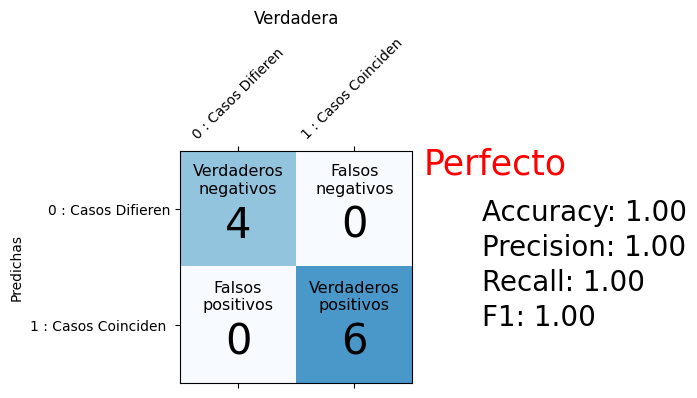

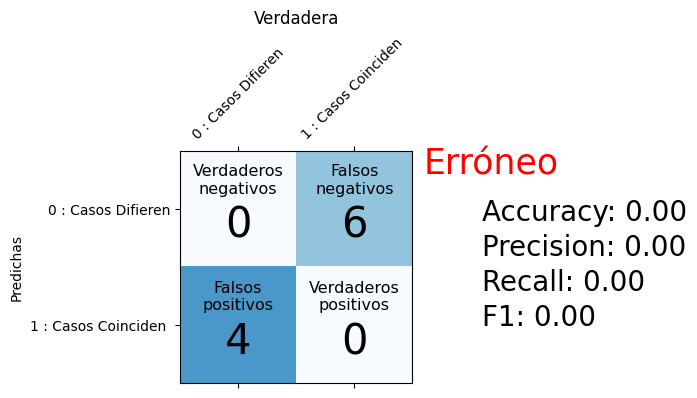

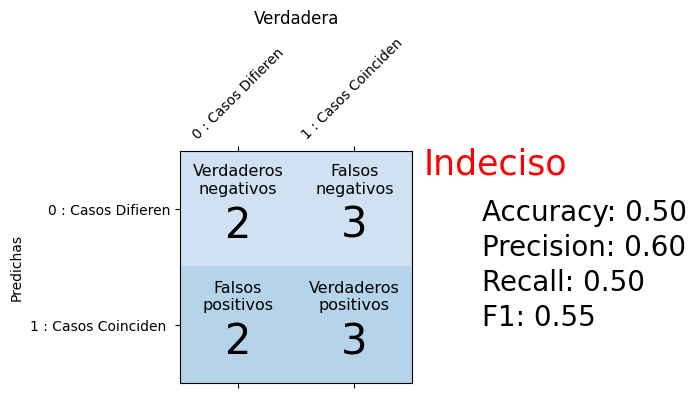

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


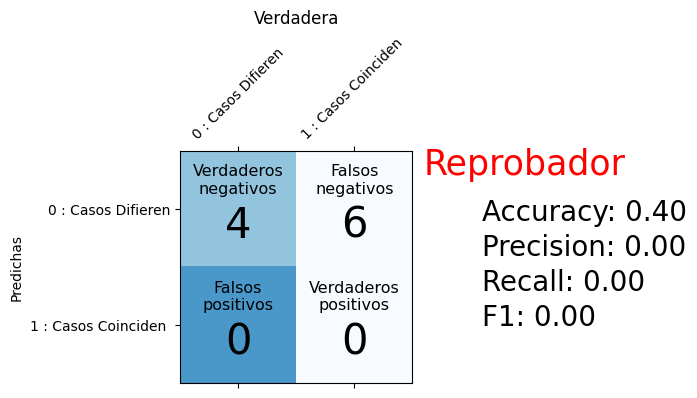

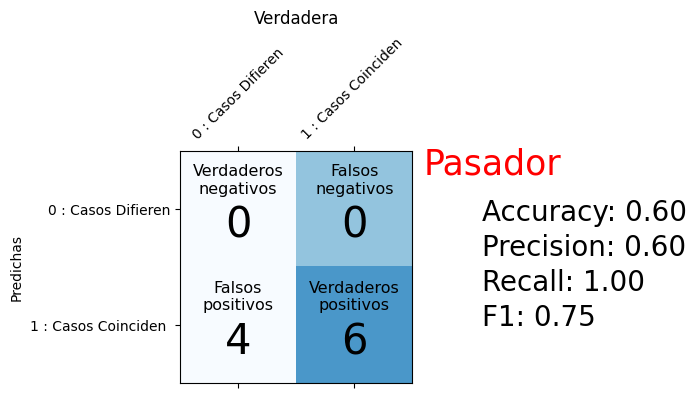

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Dominio del Ejemplo - Casos que coinciden y difieren
#
# 0 : Casos Difieren      40% Difieren
# 1 : Casos Coinciden       60% Coinciden

def metricas(clases_verdadera, clases_predichas):
    """ Calcular las métricas utilizando sklearn """
    matriz = confusion_matrix(clases_verdadera, clases_predichas)
    accuracy = accuracy_score(clases_verdadera, clases_predichas)
    precision = precision_score(clases_verdadera, clases_predichas)
    recall = recall_score(clases_verdadera, clases_predichas)
    f1 = f1_score(clases_verdadera, clases_predichas)
    return matriz, accuracy, precision, recall, f1

def visualiza_metricas(clases_verdadera, clases_predichas, titulo):
    """ Visualiza la matriz de confusión y métricas """

    #Código para calcular las métricas y matriz de confusión

    matriz, accuracy, precision, recall, f1 = \
                    metricas(clases_verdadera, clases_predichas)

    #Código de matplotlib para graficar
    plt.figure(figsize=(3, 3))
    matriz = pd.DataFrame(matriz,
                          columns=["0 : Casos Difieren", "1 : Casos Coinciden "])
    plt.matshow(matriz, cmap="Blues", vmin=0, vmax=10, fignum=1)
    plt.title("Verdadera")
    plt.ylabel("Predichas")
    plt.xticks(range(len(matriz.columns)), matriz.columns, rotation=45)
    plt.yticks(range(len(matriz.columns)), matriz.columns)
    etiquetas = (("Verdaderos\nnegativos", "Falsos\npositivos"),
                 ("Falsos\nnegativos", "Verdaderos\npositivos"))
    for i in range(len(matriz.columns)):
        for j in range(len(matriz.columns)):
            plt.text(i, j + 0.14, str(matriz.iloc[i, j]),
                     fontsize=30, ha="center", va="center")
            plt.text(i, j - 0.25, etiquetas[i][j],
                     fontsize=11.5, ha="center", va="center")
    plt.text(1.60, -0.30, titulo, fontsize=25, c="red")
    plt.text(2.1, 0.10, "Accuracy: %0.2f" % accuracy, fontsize=20)
    plt.text(2.1, 0.40, "Precision: %0.2f" % precision, fontsize=20)
    plt.text(2.1, 0.70, "Recall: %0.2f" % recall, fontsize=20)
    plt.text(2.1, 1.00, "F1: %0.2f" % f1, fontsize=20)
    plt.show()
    print("\n" * 10)

print("\n" * 10)

# Dominio del Ejemplo - Calificaciones en Exámenes
#
# 0 : Reprueba      40% Reprueba
# 1 : Aprueba       60% Aprueba

clases_reales = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

# Clasificador perfecto
clases_predichas = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
visualiza_metricas(clases_reales, clases_predichas, "Perfecto")

# Clasificador totalmente erróneo
clases_predichas = [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
visualiza_metricas(clases_reales, clases_predichas, "Erróneo")

# Clasificador indeciso
clases_predichas = [1, 1, 0, 0, 0, 0, 0, 1, 1, 1]
visualiza_metricas(clases_reales, clases_predichas, "Indeciso")

# Clasificador reprobador
clases_predichas = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
visualiza_metricas(clases_reales, clases_predichas, "Reprobador")

# Clasificador pasador
clases_predichas = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
visualiza_metricas(clases_reales, clases_predichas, "Pasador")
